<a href="https://colab.research.google.com/github/SemalDeSilva/TEAI/blob/Shavinda-G.M.V-IT22224248/TeaV4.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **STEP 1: SETUP + DETECT CLASSES**

In [2]:
import os, json, random
import numpy as np
import tensorflow as tf
from google.colab import drive

SEED = 123
random.seed(SEED)
np.random.seed(SEED)
tf.keras.utils.set_random_seed(SEED)

drive.mount('/content/drive')

# ✅ Your actual dataset root
DATASET_PATH = '/content/drive/MyDrive/Tea/Teaa/'

SAVE_DIR = '/content/drive/MyDrive/TEAI_Models/'
os.makedirs(SAVE_DIR, exist_ok=True)

MODEL_SAVE_PATH = os.path.join(SAVE_DIR, 'custom_v2.keras')
META_SAVE_PATH  = os.path.join(SAVE_DIR, 'custom_v2_meta.json')
SPLIT_SAVE_PATH = os.path.join(SAVE_DIR, 'split_files.csv')

IMG_SIZE   = 224
BATCH_SIZE = 32

# Detect class folders automatically (whatever folders exist inside Teaa/)
class_folders = sorted([
    d for d in os.listdir(DATASET_PATH)
    if os.path.isdir(os.path.join(DATASET_PATH, d)) and not d.startswith(".")
])

print("Detected class folders inside Teaa/:", class_folders)
assert len(class_folders) >= 2, "Need at least 2 class folders inside Teaa/"

NUM_CLASSES = len(class_folders)

# Save meta now (so you can always reload later)
meta = {"classes": class_folders, "img_size": IMG_SIZE, "dataset_path": DATASET_PATH}
with open(META_SAVE_PATH, "w") as f:
    json.dump(meta, f, indent=2)

print("NUM_CLASSES:", NUM_CLASSES)
print("Saved meta:", META_SAVE_PATH)

Mounted at /content/drive
Detected class folders inside Teaa/: ['Below Best', 'Best', 'Poor']
NUM_CLASSES: 3
Saved meta: /content/drive/MyDrive/TEAI_Models/custom_v2_meta.json


# **STEP 2: STRATIFIED SPLIT + tf.data PIPELINE**

In [3]:
import glob
import pandas as pd

try:
    from sklearn.model_selection import train_test_split
except Exception:
    !pip -q install scikit-learn
    from sklearn.model_selection import train_test_split

def list_images(folder):
    exts = ("*.jpg","*.jpeg","*.png","*.JPG","*.JPEG","*.PNG")
    files = []
    for e in exts:
        files.extend(glob.glob(os.path.join(folder, e)))
    return sorted(files)

# Build dataframe of (path, label)
rows = []
for cls in class_folders:
    cls_dir = os.path.join(DATASET_PATH, cls)
    for f in list_images(cls_dir):
        rows.append((f, cls))

df = pd.DataFrame(rows, columns=["path", "label"])
print("Total images:", len(df))
print(df["label"].value_counts())

assert len(df) > 0, "No images found. Check folder names and that images exist."

# Load split if already saved (so you don't change test set by accident)
if os.path.exists(SPLIT_SAVE_PATH):
    split_df = pd.read_csv(SPLIT_SAVE_PATH)
    print("Loaded existing split:", SPLIT_SAVE_PATH)
else:
    train_df, temp_df = train_test_split(
        df, test_size=0.30, random_state=SEED, stratify=df["label"]
    )
    val_df, test_df = train_test_split(
        temp_df, test_size=0.50, random_state=SEED, stratify=temp_df["label"]
    )

    train_df = train_df.assign(split="train")
    val_df   = val_df.assign(split="val")
    test_df  = test_df.assign(split="test")

    split_df = pd.concat([train_df, val_df, test_df], axis=0).reset_index(drop=True)
    split_df.to_csv(SPLIT_SAVE_PATH, index=False)
    print("Saved split:", SPLIT_SAVE_PATH)

print(split_df["split"].value_counts())
print(split_df.groupby(["split","label"]).size())

label_to_id = {c:i for i,c in enumerate(class_folders)}

def load_image(path, label_id):
    img_bytes = tf.io.read_file(path)
    img = tf.image.decode_image(img_bytes, channels=3, expand_animations=False)
    img = tf.image.resize(img, (IMG_SIZE, IMG_SIZE))
    img = tf.cast(img, tf.float32) / 255.0
    y = tf.one_hot(label_id, depth=NUM_CLASSES)
    return img, y

def make_ds(split_name, training=False):
    sub = split_df[split_df["split"] == split_name].copy()
    paths  = sub["path"].values.astype(str)
    labels = sub["label"].map(label_to_id).values.astype(np.int32)

    ds = tf.data.Dataset.from_tensor_slices((paths, labels))
    if training:
        ds = ds.shuffle(2000, seed=SEED, reshuffle_each_iteration=True)

    ds = ds.map(lambda p,y: load_image(p,y), num_parallel_calls=tf.data.AUTOTUNE)
    ds = ds.batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)
    return ds

train_ds = make_ds("train", training=True)
val_ds   = make_ds("val", training=False)
test_ds  = make_ds("test", training=False)

print("Datasets ready ✅")

Total images: 718
label
Best          353
Poor          243
Below Best    122
Name: count, dtype: int64
Saved split: /content/drive/MyDrive/TEAI_Models/split_files.csv
split
train    502
val      108
test     108
Name: count, dtype: int64
split  label     
test   Below Best     19
       Best           53
       Poor           36
train  Below Best     85
       Best          247
       Poor          170
val    Below Best     18
       Best           53
       Poor           37
dtype: int64
Datasets ready ✅


# **STEP** 3: BUILD + COMPILE MODEL


In [4]:
from tensorflow.keras import layers, models, regularizers

def build_teai_custom_model_v2():
    inputs = layers.Input(shape=(IMG_SIZE, IMG_SIZE, 3))

    # Safe augmentation (no vertical flip)
    x = layers.RandomFlip("horizontal")(inputs)
    x = layers.RandomRotation(0.10)(x)

    # Block 1
    x = layers.Conv2D(32, 5, padding="same", use_bias=False)(x)
    x = layers.BatchNormalization()(x)
    x = layers.Activation("relu")(x)
    x = layers.MaxPooling2D()(x)

    # Block 2
    x = layers.Conv2D(64, 3, padding="same", use_bias=False)(x)
    x = layers.BatchNormalization()(x)
    x = layers.Activation("relu")(x)
    x = layers.MaxPooling2D()(x)
    x = layers.SpatialDropout2D(0.15)(x)

    # Block 3
    x = layers.Conv2D(128, 3, padding="same", use_bias=False)(x)
    x = layers.BatchNormalization()(x)
    x = layers.Activation("relu")(x)
    x = layers.MaxPooling2D()(x)
    x = layers.SpatialDropout2D(0.15)(x)

    # Parameter saver
    x = layers.GlobalAveragePooling2D()(x)

    # Head
    x = layers.Dense(128, activation="relu", kernel_regularizer=regularizers.l2(1e-4))(x)
    x = layers.Dropout(0.4)(x)

    outputs = layers.Dense(NUM_CLASSES, activation="softmax")(x)
    return models.Model(inputs, outputs, name="TEAI_Custom_Model_v2")

# Load model if already trained (so no retrain next time)
if os.path.exists(MODEL_SAVE_PATH):
    model = tf.keras.models.load_model(MODEL_SAVE_PATH)
    print("Loaded existing model:", MODEL_SAVE_PATH)
else:
    model = build_teai_custom_model_v2()
    print("Built new model.")

loss_fn = tf.keras.losses.CategoricalCrossentropy(label_smoothing=0.08)

model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=5e-4),
    loss=loss_fn,
    metrics=["accuracy"]
)

model.summary()

Built new model.


Model: "TEAI_Custom_Model_v2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ random_flip (RandomFlip)        │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ random_rotation                 │ (None, 224, 224, 3)    │             0 │
│ (RandomRotation)                │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 224, 224, 32)   │         2,400 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 224, 224, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation (Activation)         │ (None, 224, 224, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 112, 112, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 112, 112, 64)   │        18,432 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 112, 112, 64)   │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_1 (Activation)       │ (None, 112, 112, 64)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 56, 56, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ spatial_dropout2d               │ (None, 56, 56, 64)     │             0 │
│ (SpatialDropout2D)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 56, 56, 128)    │        73,728 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 56, 56, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_2 (Activation)       │ (None, 56, 56, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 28, 28, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ spatial_dropout2d_1             │ (None, 28, 28, 128)    │             0 │
│ (SpatialDropout2D)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 128)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │        16,512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 3)              │           387 │
└─────────────────────────────────┴────────────────────────┴─────────────

 Total params: 112,355 (438.89 KB)

 Trainable params: 111,907 (437.14 KB)

 Non-trainable params: 448 (1.75 KB)

# **STEP 4: TRAIN + TEST EVALUATION + SAVE**

In [7]:
from sklearn.metrics import confusion_matrix, classification_report

callbacks = [
    tf.keras.callbacks.ModelCheckpoint(
        MODEL_SAVE_PATH, save_best_only=True, monitor="val_accuracy", verbose=1
    ),
    tf.keras.callbacks.EarlyStopping(
        patience=10, restore_best_weights=True, monitor="val_accuracy", verbose=1
    ),
    tf.keras.callbacks.ReduceLROnPlateau(
        patience=3, factor=0.5, monitor="val_loss", verbose=1
    )
]

if not os.path.exists(MODEL_SAVE_PATH):
    print("\n--- Starting Training ---")
    history = model.fit(
        train_ds,
        validation_data=val_ds,
        epochs=50,
        callbacks=callbacks
    )
    print("\n--- Training Complete! Model saved to:", MODEL_SAVE_PATH)
else:
    print("\nSkipping training because model already exists ✅")

# Load best saved version
model = tf.keras.models.load_model(MODEL_SAVE_PATH)

# Real TEST evaluation
test_loss, test_acc = model.evaluate(test_ds, verbose=0)
print(f"\nTEST Accuracy: {test_acc:.4f} | TEST Loss: {test_loss:.4f}")

# Confusion matrix + classification report
y_true, y_pred = [], []
for xb, yb in test_ds:
    probs = model.predict(xb, verbose=0)
    y_pred.extend(np.argmax(probs, axis=1).tolist())
    y_true.extend(np.argmax(yb.numpy(), axis=1).tolist())

cm = confusion_matrix(y_true, y_pred)
print("\nConfusion Matrix:\n", cm)

print("\nClassification Report:\n")
print(classification_report(
    y_true, y_pred, target_names=class_folders, digits=4
))

print("\nSaved files:")
print(" Model:", MODEL_SAVE_PATH)
print(" Meta :", META_SAVE_PATH)
print(" Split:", SPLIT_SAVE_PATH)


Skipping training because model already exists ✅

TEST Accuracy: 0.4907 | TEST Loss: 1.0759

Confusion Matrix:
 [[ 0 19  0]
 [ 0 53  0]
 [ 0 36  0]]

Classification Report:

              precision    recall  f1-score   support

  Below Best     0.0000    0.0000    0.0000        19
        Best     0.4907    1.0000    0.6584        53
        Poor     0.0000    0.0000    0.0000        36

    accuracy                         0.4907       108
   macro avg     0.1636    0.3333    0.2195       108
weighted avg     0.2408    0.4907    0.3231       108


Saved files:
 Model: /content/drive/MyDrive/TEAI_Models/custom_v2.keras
 Meta : /content/drive/MyDrive/TEAI_Models/custom_v2_meta.json
 Split: /content/drive/MyDrive/TEAI_Models/split_files.csv


/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [8]:
import pandas as pd, numpy as np

print("Class order (important):", class_folders)

print("\nTrain distribution:")
print(split_df[split_df["split"]=="train"]["label"].value_counts())

print("\nVal distribution:")
print(split_df[split_df["split"]=="val"]["label"].value_counts())

print("\nTest distribution:")
print(split_df[split_df["split"]=="test"]["label"].value_counts())

Class order (important): ['Below Best', 'Best', 'Poor']

Train distribution:
label
Best          247
Poor          170
Below Best     85
Name: count, dtype: int64

Val distribution:
label
Best          53
Poor          37
Below Best    18
Name: count, dtype: int64

Test distribution:
label
Best          53
Poor          36
Below Best    19
Name: count, dtype: int64


In [9]:
import os, time

MODEL_SAVE_PATH = "/content/drive/MyDrive/TEAI_Models/custom_v2.keras"

if os.path.exists(MODEL_SAVE_PATH):
    new_name = MODEL_SAVE_PATH.replace(".keras", f"_old_{int(time.time())}.keras")
    os.rename(MODEL_SAVE_PATH, new_name)
    print("Renamed old model to:", new_name)

Renamed old model to: /content/drive/MyDrive/TEAI_Models/custom_v2_old_1772606941.keras


In [10]:
import os

# keep old custom_v2.keras safe
MODEL_SAVE_PATH = "/content/drive/MyDrive/TEAI_Models/custom_v2_balanced.keras"
print("Will save new model to:", MODEL_SAVE_PATH)

Will save new model to: /content/drive/MyDrive/TEAI_Models/custom_v2_balanced.keras


In [11]:
import numpy as np
from sklearn.utils.class_weight import compute_class_weight

# label_to_id should already exist from your split pipeline
train_labels = split_df[split_df["split"]=="train"]["label"].map(label_to_id).values

weights = compute_class_weight(
    class_weight="balanced",
    classes=np.arange(len(class_folders)),
    y=train_labels
)
class_weight = {i: float(w) for i, w in enumerate(weights)}

print("Class weights:")
for i, w in class_weight.items():
    print(f"  {class_folders[i]}: {w:.3f}")

Class weights:
  Below Best: 1.969
  Best: 0.677
  Poor: 0.984


In [12]:
import tensorflow as tf

loss_fn = tf.keras.losses.CategoricalCrossentropy(label_smoothing=0.0)

model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=3e-4),
    loss=loss_fn,
    metrics=["accuracy"]
)

In [13]:
callbacks = [
    tf.keras.callbacks.ModelCheckpoint(
        MODEL_SAVE_PATH, save_best_only=True, monitor="val_loss", mode="min", verbose=1
    ),
    tf.keras.callbacks.EarlyStopping(
        patience=10, restore_best_weights=True, monitor="val_loss", mode="min", verbose=1
    ),
    tf.keras.callbacks.ReduceLROnPlateau(
        patience=3, factor=0.5, monitor="val_loss", verbose=1
    )
]

In [14]:
history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=50,
    callbacks=callbacks,
    class_weight=class_weight
)

Epoch 1/50
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 7s/step - accuracy: 0.4907 - loss: 1.1328
Epoch 1: val_loss improved from inf to 1.08600, saving model to /content/drive/MyDrive/TEAI_Models/custom_v2_balanced.keras
16/16 ━━━━━━━━━━━━━━━━━━━━ 137s 8s/step - accuracy: 0.4911 - loss: 1.1300 - val_accuracy: 0.4815 - val_loss: 1.0860 - learning_rate: 3.0000e-04
Epoch 2/50
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 8s/step - accuracy: 0.4703 - loss: 0.9805
Epoch 2: val_loss did not improve from 1.08600
16/16 ━━━━━━━━━━━━━━━━━━━━ 134s 8s/step - accuracy: 0.4729 - loss: 0.9789 - val_accuracy: 0.1667 - val_loss: 1.1273 - learning_rate: 3.0000e-04
Epoch 3/50
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 7s/step - accuracy: 0.5971 - loss: 0.8626
Epoch 3: val_loss did not improve from 1.08600
16/16 ━━━━━━━━━━━━━━━━━━━━ 126s 7s/step - accuracy: 0.5956 - loss: 0.8617 - val_accuracy: 0.1667 - val_loss: 1.1743 - learning_rate: 3.0000e-04
Epoch 4/50
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 7s/step - accuracy: 0.6154 - loss: 0.7867
Epoch 4: val_loss 

In [15]:
import numpy as np
import tensorflow as tf

model_path = "/content/drive/MyDrive/TEAI_Models/custom_v2_balanced.keras"
m = tf.keras.models.load_model(model_path)

pred_counts = np.zeros(len(class_folders), dtype=int)

for xb, yb in val_ds:
    probs = m.predict(xb, verbose=0)
    preds = np.argmax(probs, axis=1)
    for p in preds:
        pred_counts[p] += 1

print("Predicted counts on VAL:")
for i, c in enumerate(class_folders):
    print(f"{c}: {pred_counts[i]}")

Predicted counts on VAL:
Below Best: 0
Best: 107
Poor: 1


In [16]:
import numpy as np
import tensorflow as tf

AUTOTUNE = tf.data.AUTOTUNE

def load_image_int(path, label_id):
    img_bytes = tf.io.read_file(path)
    img = tf.image.decode_image(img_bytes, channels=3, expand_animations=False)
    img = tf.image.resize(img, (IMG_SIZE, IMG_SIZE))
    img = tf.cast(img, tf.float32) / 255.0
    return img, tf.cast(label_id, tf.int32)

In [17]:
def make_balanced_train_ds():
    train_sub = split_df[split_df["split"]=="train"].copy()

    ds_list = []
    for cls in class_folders:
        paths = train_sub[train_sub["label"] == cls]["path"].values.astype(str)
        labels = np.full(len(paths), label_to_id[cls], dtype=np.int32)

        ds = tf.data.Dataset.from_tensor_slices((paths, labels))
        ds = ds.shuffle(len(paths), seed=SEED, reshuffle_each_iteration=True)
        ds = ds.map(load_image_int, num_parallel_calls=AUTOTUNE).repeat()  # repeat for infinite stream
        ds_list.append(ds)

    # equal probability sampling
    balanced = tf.data.Dataset.sample_from_datasets(
        ds_list,
        weights=[1/len(ds_list)] * len(ds_list),
        seed=SEED
    )

    balanced = balanced.batch(BATCH_SIZE).prefetch(AUTOTUNE)
    return balanced

train_ds_balanced = make_balanced_train_ds()

# val/test normal (not balanced)
def make_ds_int(split_name):
    sub = split_df[split_df["split"] == split_name].copy()
    paths  = sub["path"].values.astype(str)
    labels = sub["label"].map(label_to_id).values.astype(np.int32)

    ds = tf.data.Dataset.from_tensor_slices((paths, labels))
    ds = ds.map(load_image_int, num_parallel_calls=AUTOTUNE)
    ds = ds.batch(BATCH_SIZE).prefetch(AUTOTUNE)
    return ds

val_ds_int  = make_ds_int("val")
test_ds_int = make_ds_int("test")

print("Balanced train ds + int val/test ds ready ✅")

Balanced train ds + int val/test ds ready ✅


In [18]:
MODEL_SAVE_PATH = "/content/drive/MyDrive/TEAI_Models/custom_v2_balanced_sampling.keras"

# IMPORTANT: rebuild fresh (don’t load old collapsed weights)
model = build_teai_custom_model_v2()

model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-4),
    loss=tf.keras.losses.SparseCategoricalCrossentropy(),
    metrics=["accuracy"]
)
model.summary()

Model: "TEAI_Custom_Model_v2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ random_flip_1 (RandomFlip)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ random_rotation_1               │ (None, 224, 224, 3)    │             0 │
│ (RandomRotation)                │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 224, 224, 32)   │         2,400 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 224, 224, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_3 (Activation)       │ (None, 224, 224, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 112, 112, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 112, 112, 64)   │        18,432 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 112, 112, 64)   │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_4 (Activation)       │ (None, 112, 112, 64)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 56, 56, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ spatial_dropout2d_2             │ (None, 56, 56, 64)     │             0 │
│ (SpatialDropout2D)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 56, 56, 128)    │        73,728 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_5           │ (None, 56, 56, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_5 (Activation)       │ (None, 56, 56, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 28, 28, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ spatial_dropout2d_3             │ (None, 28, 28, 128)    │             0 │
│ (SpatialDropout2D)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_1      │ (None, 128)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │        16,512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 3)              │           387 │
└─────────────────────────────────┴────────────────────────┴─────────────

 Total params: 112,355 (438.89 KB)

 Trainable params: 111,907 (437.14 KB)

 Non-trainable params: 448 (1.75 KB)

In [19]:
# how many batches per epoch (roughly based on train size)
train_size = len(split_df[split_df["split"]=="train"])
steps_per_epoch = int(np.ceil(train_size / BATCH_SIZE))

callbacks = [
    tf.keras.callbacks.ModelCheckpoint(
        MODEL_SAVE_PATH, save_best_only=True, monitor="val_loss", mode="min", verbose=1
    ),
    tf.keras.callbacks.EarlyStopping(
        patience=10, restore_best_weights=True, monitor="val_loss", mode="min", verbose=1
    ),
    tf.keras.callbacks.ReduceLROnPlateau(
        patience=3, factor=0.5, monitor="val_loss", verbose=1
    )
]

history = model.fit(
    train_ds_balanced,
    validation_data=val_ds_int,
    epochs=50,
    steps_per_epoch=steps_per_epoch,
    callbacks=callbacks
)

Epoch 1/50
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 7s/step - accuracy: 0.3984 - loss: 1.2186
Epoch 1: val_loss improved from inf to 1.10477, saving model to /content/drive/MyDrive/TEAI_Models/custom_v2_balanced_sampling.keras
16/16 ━━━━━━━━━━━━━━━━━━━━ 140s 8s/step - accuracy: 0.3981 - loss: 1.2171 - val_accuracy: 0.4907 - val_loss: 1.1048 - learning_rate: 1.0000e-04
Epoch 2/50
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 7s/step - accuracy: 0.4128 - loss: 1.1345
Epoch 2: val_loss did not improve from 1.10477
16/16 ━━━━━━━━━━━━━━━━━━━━ 129s 8s/step - accuracy: 0.4128 - loss: 1.1335 - val_accuracy: 0.3611 - val_loss: 1.1116 - learning_rate: 1.0000e-04
Epoch 3/50
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 7s/step - accuracy: 0.4039 - loss: 1.1189
Epoch 3: val_loss did not improve from 1.10477
16/16 ━━━━━━━━━━━━━━━━━━━━ 127s 8s/step - accuracy: 0.4049 - loss: 1.1187 - val_accuracy: 0.1667 - val_loss: 1.1288 - learning_rate: 1.0000e-04
Epoch 4/50
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 7s/step - accuracy: 0.4089 - loss: 1.0711
Epoch 4: 

KeyboardInterrupt: 

In [20]:
import numpy as np

xb, yb = next(iter(train_ds_balanced))   # balanced train
# yb should be int labels (Sparse setup)
vals, counts = np.unique(yb.numpy(), return_counts=True)

print("Class order:", class_folders)
print("Batch label counts:")
for v, c in zip(vals, counts):
    print(f"  {v} ({class_folders[int(v)]}): {c}")

Class order: ['Below Best', 'Best', 'Poor']
Batch label counts:
  0 (Below Best): 6
  1 (Best): 13
  2 (Poor): 13


In [21]:
import tensorflow as tf
import numpy as np

TRAIN_BATCH_SIZE = 30  # 10 per class
PER_CLASS = TRAIN_BATCH_SIZE // len(class_folders)  # = 10

def make_perfect_balanced_train_ds():
    train_sub = split_df[split_df["split"]=="train"].copy()

    per_class_ds = []
    for cls in class_folders:
        paths = train_sub[train_sub["label"]==cls]["path"].values.astype(str)
        labels = np.full(len(paths), label_to_id[cls], dtype=np.int32)

        ds = tf.data.Dataset.from_tensor_slices((paths, labels))
        ds = ds.shuffle(len(paths), seed=SEED, reshuffle_each_iteration=True)
        ds = ds.map(load_image_int, num_parallel_calls=tf.data.AUTOTUNE)
        ds = ds.repeat()
        ds = ds.batch(PER_CLASS, drop_remainder=True)  # ✅ fixed-size mini-batches per class
        per_class_ds.append(ds)

    # zip -> each step gives (batch_belowbest, batch_best, batch_poor)
    zipped = tf.data.Dataset.zip(tuple(per_class_ds))

    # merge into one balanced batch and shuffle inside the batch
    def merge_batches(*batches):
        xs = tf.concat([b[0] for b in batches], axis=0)
        ys = tf.concat([b[1] for b in batches], axis=0)
        idx = tf.random.shuffle(tf.range(tf.shape(xs)[0]), seed=SEED)
        xs = tf.gather(xs, idx)
        ys = tf.gather(ys, idx)
        return xs, ys

    ds = zipped.map(merge_batches, num_parallel_calls=tf.data.AUTOTUNE)
    ds = ds.prefetch(tf.data.AUTOTUNE)
    return ds

train_ds_balanced = make_perfect_balanced_train_ds()
print("Perfect balanced train_ds ready ✅")

Perfect balanced train_ds ready ✅


In [22]:
import tensorflow as tf

xb, yb = next(iter(train_ds_balanced))
print("min/max:", float(tf.reduce_min(xb)), float(tf.reduce_max(xb)))

min/max: 0.0 1.0


In [23]:
import pandas as pd
import tensorflow as tf
from tensorflow.keras import layers, models

# tiny dataset: 10 images per class
small_rows = []
for cls in class_folders:
    sub = split_df[(split_df["split"]=="train") & (split_df["label"]==cls)].head(10)
    small_rows.append(sub)
small_df = pd.concat(small_rows).reset_index(drop=True)

paths  = small_df["path"].values.astype(str)
labels = small_df["label"].map(label_to_id).values.astype(np.int32)

tiny_ds = tf.data.Dataset.from_tensor_slices((paths, labels))
tiny_ds = tiny_ds.shuffle(200, seed=SEED).map(load_image_int).batch(16).repeat()

# simple model, no augmentation, no dropout
tf.keras.backend.clear_session()
tiny_model = models.Sequential([
    layers.Input((IMG_SIZE, IMG_SIZE, 3)),
    layers.Conv2D(16, 3, activation="relu"),
    layers.MaxPooling2D(),
    layers.Conv2D(32, 3, activation="relu"),
    layers.MaxPooling2D(),
    layers.GlobalAveragePooling2D(),
    layers.Dense(len(class_folders), activation="softmax")
])

tiny_model.compile(
    optimizer=tf.keras.optimizers.Adam(1e-3),
    loss=tf.keras.losses.SparseCategoricalCrossentropy(),
    metrics=["accuracy"]
)

hist = tiny_model.fit(tiny_ds, steps_per_epoch=10, epochs=20, verbose=1)

Epoch 1/20
10/10 ━━━━━━━━━━━━━━━━━━━━ 16s 1s/step - accuracy: 0.3260 - loss: 1.1029
Epoch 2/20
10/10 ━━━━━━━━━━━━━━━━━━━━ 10s 1s/step - accuracy: 0.3410 - loss: 1.0993
Epoch 3/20
10/10 ━━━━━━━━━━━━━━━━━━━━ 8s 797ms/step - accuracy: 0.3877 - loss: 1.0972
Epoch 4/20
10/10 ━━━━━━━━━━━━━━━━━━━━ 11s 1s/step - accuracy: 0.3454 - loss: 1.0965
Epoch 5/20
10/10 ━━━━━━━━━━━━━━━━━━━━ 8s 845ms/step - accuracy: 0.3824 - loss: 1.0953
Epoch 6/20
10/10 ━━━━━━━━━━━━━━━━━━━━ 10s 932ms/step - accuracy: 0.4420 - loss: 1.0953
Epoch 7/20
10/10 ━━━━━━━━━━━━━━━━━━━━ 10s 1s/step - accuracy: 0.4041 - loss: 1.0946
Epoch 8/20
10/10 ━━━━━━━━━━━━━━━━━━━━ 8s 763ms/step - accuracy: 0.4650 - loss: 1.0945
Epoch 9/20
10/10 ━━━━━━━━━━━━━━━━━━━━ 10s 1s/step - accuracy: 0.4026 - loss: 1.0930
Epoch 10/20
10/10 ━━━━━━━━━━━━━━━━━━━━ 8s 770ms/step - accuracy: 0.4420 - loss: 1.0921
Epoch 11/20
10/10 ━━━━━━━━━━━━━━━━━━━━ 10s 989ms/step - accuracy: 0.4375 - loss: 1.0912
Epoch 12/20
10/10 ━━━━━━━━━━━━━━━━━━━━ 9s 934ms/step - accur

In [24]:
import os, glob, hashlib
from collections import defaultdict

DATASET_PATH = "/content/drive/MyDrive/Tea/Teaa/"
class_folders = sorted([d for d in os.listdir(DATASET_PATH) if os.path.isdir(os.path.join(DATASET_PATH, d))])

def list_images(folder):
    exts = ("*.jpg","*.jpeg","*.png","*.JPG","*.JPEG","*.PNG")
    files = []
    for e in exts:
        files.extend(glob.glob(os.path.join(folder, e)))
    return files

def md5_file(path, chunk=1024*1024):
    h = hashlib.md5()
    with open(path, "rb") as f:
        while True:
            b = f.read(chunk)
            if not b:
                break
            h.update(b)
    return h.hexdigest()

hash_map = defaultdict(list)

for cls in class_folders:
    for p in list_images(os.path.join(DATASET_PATH, cls)):
        try:
            hash_map[md5_file(p)].append((cls, p))
        except Exception:
            pass

# Duplicates across different classes
cross_class_dupes = []
for h, items in hash_map.items():
    classes = set([c for c,_ in items])
    if len(items) > 1 and len(classes) > 1:
        cross_class_dupes.append((h, items))

print("Classes:", class_folders)
print("Total files scanned:", sum(len(list_images(os.path.join(DATASET_PATH, c))) for c in class_folders))
print("Cross-class exact duplicate groups:", len(cross_class_dupes))

# show a few examples
for i, (h, items) in enumerate(cross_class_dupes[:5]):
    print("\nDuplicate group", i+1, "hash:", h)
    for cls, path in items:
        print(" ", cls, "->", path)

Classes: ['Below Best', 'Best', 'Poor']
Total files scanned: 718
Cross-class exact duplicate groups: 0


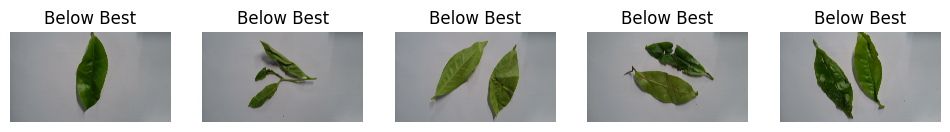

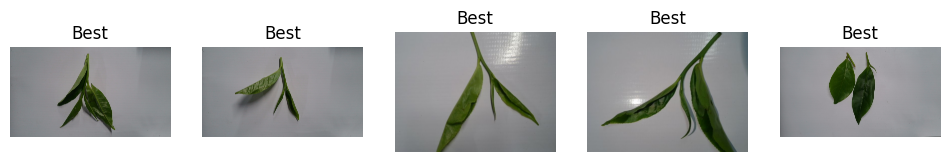

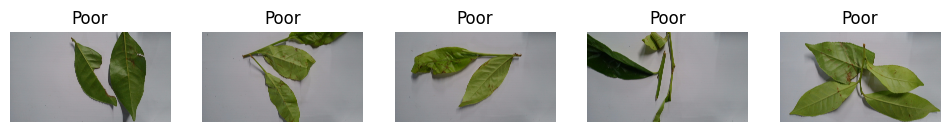

In [25]:
import matplotlib.pyplot as plt
import random
from PIL import Image

def show_random_images(cls, n=6):
    folder = os.path.join(DATASET_PATH, cls)
    files = list_images(folder)
    files = random.sample(files, min(n, len(files)))

    plt.figure(figsize=(12, 4))
    for i, f in enumerate(files):
        img = Image.open(f).convert("RGB")
        plt.subplot(1, len(files), i+1)
        plt.imshow(img)
        plt.title(cls)
        plt.axis("off")
    plt.show()

for c in class_folders:
    show_random_images(c, n=5)

In [26]:
import tensorflow as tf
from tensorflow.keras import layers, models

tf.keras.backend.clear_session()

strong_tiny = models.Sequential([
    layers.Input((224,224,3)),
    layers.Conv2D(32, 3, activation="relu"),
    layers.Conv2D(32, 3, activation="relu"),
    layers.MaxPooling2D(),

    layers.Conv2D(64, 3, activation="relu"),
    layers.Conv2D(64, 3, activation="relu"),
    layers.MaxPooling2D(),

    layers.Conv2D(128, 3, activation="relu"),
    layers.GlobalAveragePooling2D(),

    layers.Dense(128, activation="relu"),
    layers.Dense(len(class_folders), activation="softmax")
])

strong_tiny.compile(
    optimizer=tf.keras.optimizers.Adam(3e-3),
    loss=tf.keras.losses.SparseCategoricalCrossentropy(),
    metrics=["accuracy"]
)

hist = strong_tiny.fit(tiny_ds, steps_per_epoch=10, epochs=30, verbose=1)

Epoch 1/30
10/10 ━━━━━━━━━━━━━━━━━━━━ 54s 5s/step - accuracy: 0.2850 - loss: 1.1080
Epoch 2/30
10/10 ━━━━━━━━━━━━━━━━━━━━ 44s 4s/step - accuracy: 0.3186 - loss: 1.0987
Epoch 3/30
10/10 ━━━━━━━━━━━━━━━━━━━━ 43s 4s/step - accuracy: 0.3029 - loss: 1.0989
Epoch 4/30
10/10 ━━━━━━━━━━━━━━━━━━━━ 45s 4s/step - accuracy: 0.3414 - loss: 1.0986
Epoch 5/30
10/10 ━━━━━━━━━━━━━━━━━━━━ 44s 5s/step - accuracy: 0.3469 - loss: 1.0985
Epoch 6/30
10/10 ━━━━━━━━━━━━━━━━━━━━ 43s 4s/step - accuracy: 0.3447 - loss: 1.0982
Epoch 7/30
10/10 ━━━━━━━━━━━━━━━━━━━━ 43s 4s/step - accuracy: 0.3701 - loss: 1.0887
Epoch 8/30
10/10 ━━━━━━━━━━━━━━━━━━━━ 44s 4s/step - accuracy: 0.3531 - loss: 1.0283
Epoch 9/30
10/10 ━━━━━━━━━━━━━━━━━━━━ 44s 5s/step - accuracy: 0.5468 - loss: 0.9353
Epoch 10/30
10/10 ━━━━━━━━━━━━━━━━━━━━ 43s 4s/step - accuracy: 0.4923 - loss: 0.9425
Epoch 11/30
10/10 ━━━━━━━━━━━━━━━━━━━━ 43s 4s/step - accuracy: 0.6380 - loss: 0.8391
Epoch 12/30
10/10 ━━━━━━━━━━━━━━━━━━━━ 45s 4s/step - accuracy: 0.6727 - lo

In [27]:
import numpy as np
import tensorflow as tf

AUTOTUNE = tf.data.AUTOTUNE
TRAIN_BATCH_SIZE = 30
PER_CLASS = TRAIN_BATCH_SIZE // len(class_folders)  # 10

def load_image_int(path, label_id):
    img_bytes = tf.io.read_file(path)
    img = tf.image.decode_image(img_bytes, channels=3, expand_animations=False)
    img = tf.image.resize(img, (IMG_SIZE, IMG_SIZE))
    img = tf.cast(img, tf.float32) / 255.0
    return img, tf.cast(label_id, tf.int32)

def make_perfect_balanced_train_ds():
    train_sub = split_df[split_df["split"]=="train"].copy()

    per_class_ds = []
    for cls in class_folders:
        paths = train_sub[train_sub["label"]==cls]["path"].values.astype(str)
        labels = np.full(len(paths), label_to_id[cls], dtype=np.int32)

        ds = tf.data.Dataset.from_tensor_slices((paths, labels))
        ds = ds.shuffle(len(paths), seed=SEED, reshuffle_each_iteration=True)
        ds = ds.map(load_image_int, num_parallel_calls=AUTOTUNE)
        ds = ds.repeat()
        ds = ds.batch(PER_CLASS, drop_remainder=True)   # fixed-size per class
        per_class_ds.append(ds)

    zipped = tf.data.Dataset.zip(tuple(per_class_ds))

    def merge_batches(*batches):
        xs = tf.concat([b[0] for b in batches], axis=0)
        ys = tf.concat([b[1] for b in batches], axis=0)
        idx = tf.random.shuffle(tf.range(tf.shape(xs)[0]), seed=SEED)
        return tf.gather(xs, idx), tf.gather(ys, idx)

    ds = zipped.map(merge_batches, num_parallel_calls=AUTOTUNE)
    return ds.prefetch(AUTOTUNE)

train_ds_balanced = make_perfect_balanced_train_ds()

def make_ds_int(split_name):
    sub = split_df[split_df["split"] == split_name].copy()
    paths  = sub["path"].values.astype(str)
    labels = sub["label"].map(label_to_id).values.astype(np.int32)

    ds = tf.data.Dataset.from_tensor_slices((paths, labels))
    ds = ds.map(load_image_int, num_parallel_calls=AUTOTUNE)
    ds = ds.batch(32).prefetch(AUTOTUNE)
    return ds

val_ds_int  = make_ds_int("val")
test_ds_int = make_ds_int("test")

# Quick check
xb, yb = next(iter(train_ds_balanced))
vals, counts = np.unique(yb.numpy(), return_counts=True)
print("Balanced batch counts:", {class_folders[int(v)]: int(c) for v,c in zip(vals,counts)})

Balanced batch counts: {'Below Best': 10, 'Best': 10, 'Poor': 10}


In [28]:
from tensorflow.keras import layers, models

tf.keras.backend.clear_session()

def build_custom_strong(num_classes):
    inputs = layers.Input((IMG_SIZE, IMG_SIZE, 3))

    x = layers.Conv2D(32, 3, padding="same", use_bias=False)(inputs)
    x = layers.BatchNormalization()(x); x = layers.Activation("relu")(x)
    x = layers.Conv2D(32, 3, padding="same", use_bias=False)(x)
    x = layers.BatchNormalization()(x); x = layers.Activation("relu")(x)
    x = layers.MaxPooling2D()(x)

    x = layers.Conv2D(64, 3, padding="same", use_bias=False)(x)
    x = layers.BatchNormalization()(x); x = layers.Activation("relu")(x)
    x = layers.Conv2D(64, 3, padding="same", use_bias=False)(x)
    x = layers.BatchNormalization()(x); x = layers.Activation("relu")(x)
    x = layers.MaxPooling2D()(x)

    x = layers.Conv2D(128, 3, padding="same", use_bias=False)(x)
    x = layers.BatchNormalization()(x); x = layers.Activation("relu")(x)
    x = layers.GlobalAveragePooling2D()(x)

    x = layers.Dense(128, activation="relu")(x)
    x = layers.Dropout(0.2)(x)
    outputs = layers.Dense(num_classes, activation="softmax")(x)

    return models.Model(inputs, outputs, name="TEAI_Custom_Strong")

model = build_custom_strong(len(class_folders))

model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-4),
    loss=tf.keras.losses.SparseCategoricalCrossentropy(),
    metrics=["accuracy"]
)

model.summary()

Model: "TEAI_Custom_Strong"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 224, 224, 32)   │           864 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 224, 224, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation (Activation)         │ (None, 224, 224, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 224, 224, 32)   │         9,216 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 224, 224, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_1 (Activation)       │ (None, 224, 224, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 112, 112, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 112, 112, 64)   │        18,432 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 112, 112, 64)   │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_2 (Activation)       │ (None, 112, 112, 64)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 112, 112, 64)   │        36,864 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 112, 112, 64)   │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_3 (Activation)       │ (None, 112, 112, 64)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 56, 56, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 56, 56, 128)    │        73,728 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 56, 56, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_4 (Activation)       │ (None, 56, 56, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 128)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │        16,512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 3)              │           38

 Total params: 157,283 (614.39 KB)

 Trainable params: 156,643 (611.89 KB)

 Non-trainable params: 640 (2.50 KB)

In [29]:
import numpy as np

class PredCountCallback(tf.keras.callbacks.Callback):
    def __init__(self, val_ds, class_names):
        super().__init__()
        self.val_ds = val_ds
        self.class_names = class_names

    def on_epoch_end(self, epoch, logs=None):
        counts = np.zeros(len(self.class_names), dtype=int)
        for xb, yb in self.val_ds:
            probs = self.model.predict(xb, verbose=0)
            preds = np.argmax(probs, axis=1)
            for p in preds:
                counts[p] += 1

        msg = " | ".join([f"{self.class_names[i]}:{counts[i]}" for i in range(len(self.class_names))])
        print(f"\n[VAL prediction counts] epoch {epoch+1}: {msg}\n")

In [30]:
import os
from sklearn.metrics import confusion_matrix, classification_report

MODEL_SAVE_PATH = "/content/drive/MyDrive/TEAI_Models/custom_strong_balanced.keras"

train_size = len(split_df[split_df["split"]=="train"])
steps_per_epoch = int(np.ceil(train_size / TRAIN_BATCH_SIZE))
print("steps_per_epoch:", steps_per_epoch)

callbacks = [
    tf.keras.callbacks.ModelCheckpoint(MODEL_SAVE_PATH, save_best_only=True, monitor="val_loss", mode="min", verbose=1),
    tf.keras.callbacks.EarlyStopping(patience=8, restore_best_weights=True, monitor="val_loss", mode="min", verbose=1),
    tf.keras.callbacks.ReduceLROnPlateau(patience=3, factor=0.5, monitor="val_loss", verbose=1),
    PredCountCallback(val_ds_int, class_folders)
]

history = model.fit(
    train_ds_balanced,
    validation_data=val_ds_int,
    epochs=40,
    steps_per_epoch=steps_per_epoch,
    callbacks=callbacks
)

# Evaluate
best = tf.keras.models.load_model(MODEL_SAVE_PATH)
test_loss, test_acc = best.evaluate(test_ds_int, verbose=0)
print(f"\nTEST Accuracy: {test_acc:.4f} | TEST Loss: {test_loss:.4f}")

y_true, y_pred = [], []
for xb, yb in test_ds_int:
    probs = best.predict(xb, verbose=0)
    y_pred.extend(np.argmax(probs, axis=1).tolist())
    y_true.extend(yb.numpy().tolist())

cm = confusion_matrix(y_true, y_pred)
print("\nConfusion Matrix:\n", cm)
print("\nClassification Report:\n")
print(classification_report(y_true, y_pred, target_names=class_folders, digits=4, zero_division=0))

steps_per_epoch: 17
Epoch 1/40
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 13s/step - accuracy: 0.4355 - loss: 1.0679 
Epoch 1: val_loss improved from inf to 1.11248, saving model to /content/drive/MyDrive/TEAI_Models/custom_strong_balanced.keras

[VAL prediction counts] epoch 1: Below Best:0 | Best:0 | Poor:108

17/17 ━━━━━━━━━━━━━━━━━━━━ 281s 15s/step - accuracy: 0.4405 - loss: 1.0647 - val_accuracy: 0.3426 - val_loss: 1.1125 - learning_rate: 1.0000e-04
Epoch 2/40
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 13s/step - accuracy: 0.6261 - loss: 0.8904 
Epoch 2: val_loss did not improve from 1.11248

[VAL prediction counts] epoch 2: Below Best:108 | Best:0 | Poor:0

17/17 ━━━━━━━━━━━━━━━━━━━━ 264s 16s/step - accuracy: 0.6266 - loss: 0.8888 - val_accuracy: 0.1667 - val_loss: 1.1470 - learning_rate: 1.0000e-04
Epoch 3/40
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 13s/step - accuracy: 0.7463 - loss: 0.7218 
Epoch 3: val_loss did not improve from 1.11248

[VAL prediction counts] epoch 3: Below Best:108 | Best:0 | Poor:0

17/17 ━━━

KeyboardInterrupt: 

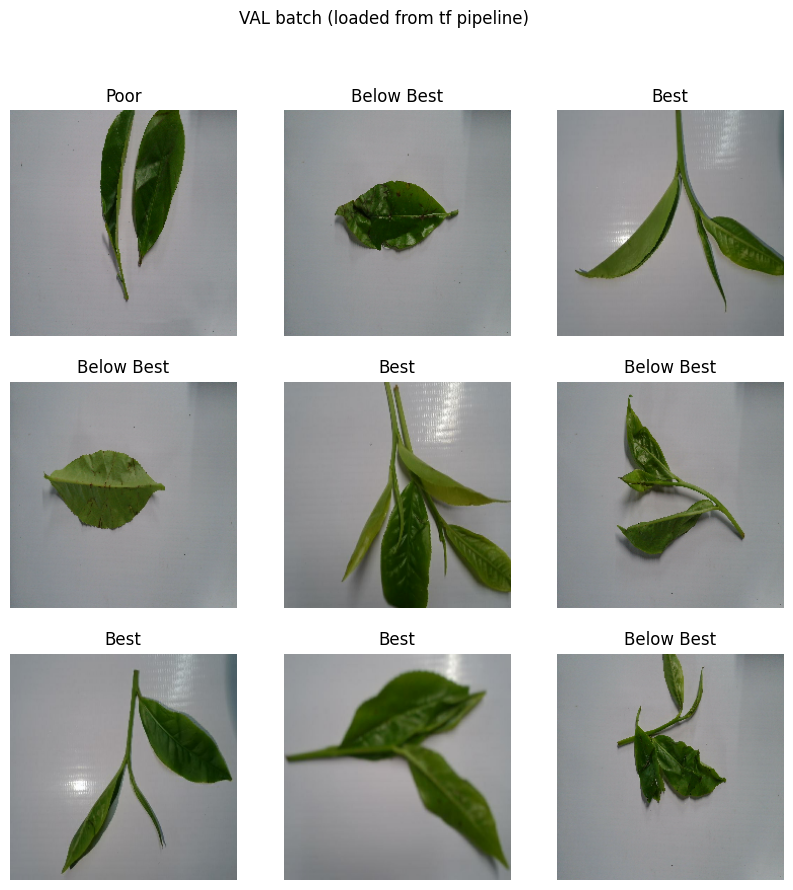

In [31]:
import matplotlib.pyplot as plt
import numpy as np

def show_batch_int(ds, title, class_names):
    x, y = next(iter(ds))
    plt.figure(figsize=(10,10))
    for i in range(9):
        plt.subplot(3,3,i+1)
        plt.imshow(x[i].numpy())
        plt.title(class_names[int(y[i].numpy())])
        plt.axis("off")
    plt.suptitle(title)
    plt.show()

show_batch_int(val_ds_int, "VAL batch (loaded from tf pipeline)", class_folders)

In [32]:
import numpy as np
import tensorflow as tf

# take one val batch
xb, yb = next(iter(val_ds_int))

# inference mode (what predict uses)
p_inf = model(xb, training=False).numpy()
pred_inf = np.argmax(p_inf, axis=1)

# "training=True" uses batch statistics (BN behaves differently)
p_tr = model(xb, training=True).numpy()
pred_tr = np.argmax(p_tr, axis=1)

def counts(pred):
    out = {c:0 for c in class_folders}
    for k in pred:
        out[class_folders[int(k)]] += 1
    return out

print("Pred counts (training=False):", counts(pred_inf))
print("Pred counts (training=True) :", counts(pred_tr))

Pred counts (training=False): {'Below Best': 32, 'Best': 0, 'Poor': 0}
Pred counts (training=True) : {'Below Best': 8, 'Best': 11, 'Poor': 13}


In [33]:
import tensorflow as tf
from tensorflow.keras import layers, models
from sklearn.metrics import confusion_matrix, classification_report
import numpy as np

tf.keras.backend.clear_session()

# ---- BN-FREE model ----
def build_custom_no_bn(num_classes):
    inputs = layers.Input((IMG_SIZE, IMG_SIZE, 3))

    x = layers.Conv2D(32, 3, padding="same", activation="relu")(inputs)
    x = layers.Conv2D(32, 3, padding="same", activation="relu")(x)
    x = layers.MaxPooling2D()(x)

    x = layers.Conv2D(64, 3, padding="same", activation="relu")(x)
    x = layers.Conv2D(64, 3, padding="same", activation="relu")(x)
    x = layers.MaxPooling2D()(x)

    x = layers.Conv2D(128, 3, padding="same", activation="relu")(x)
    x = layers.GlobalAveragePooling2D()(x)

    x = layers.Dense(128, activation="relu")(x)
    x = layers.Dropout(0.2)(x)
    outputs = layers.Dense(num_classes, activation="softmax")(x)

    return models.Model(inputs, outputs, name="TEAI_Custom_NoBN")

model_nobn = build_custom_no_bn(len(class_folders))

model_nobn.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-4),
    loss=tf.keras.losses.SparseCategoricalCrossentropy(),
    metrics=["accuracy"]
)

MODEL_SAVE_PATH = "/content/drive/MyDrive/TEAI_Models/custom_nobn_balanced.keras"

train_size = len(split_df[split_df["split"]=="train"])
steps_per_epoch = int(np.ceil(train_size / TRAIN_BATCH_SIZE))
print("steps_per_epoch:", steps_per_epoch)

callbacks = [
    tf.keras.callbacks.ModelCheckpoint(MODEL_SAVE_PATH, save_best_only=True, monitor="val_loss", mode="min", verbose=1),
    tf.keras.callbacks.EarlyStopping(patience=8, restore_best_weights=True, monitor="val_loss", mode="min", verbose=1),
    tf.keras.callbacks.ReduceLROnPlateau(patience=3, factor=0.5, monitor="val_loss", verbose=1),
    PredCountCallback(val_ds_int, class_folders)
]

history = model_nobn.fit(
    train_ds_balanced,
    validation_data=val_ds_int,
    epochs=40,
    steps_per_epoch=steps_per_epoch,
    callbacks=callbacks
)

# ---- Evaluate on TEST ----
best = tf.keras.models.load_model(MODEL_SAVE_PATH)
test_loss, test_acc = best.evaluate(test_ds_int, verbose=0)
print(f"\nTEST Accuracy: {test_acc:.4f} | TEST Loss: {test_loss:.4f}")

y_true, y_pred = [], []
for xb, yb in test_ds_int:
    probs = best.predict(xb, verbose=0)
    y_pred.extend(np.argmax(probs, axis=1).tolist())
    y_true.extend(yb.numpy().tolist())

cm = confusion_matrix(y_true, y_pred)
print("\nConfusion Matrix:\n", cm)
print("\nClassification Report:\n")
print(classification_report(y_true, y_pred, target_names=class_folders, digits=4, zero_division=0))

steps_per_epoch: 17
Epoch 1/40
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 10s/step - accuracy: 0.3424 - loss: 1.0989
Epoch 1: val_loss improved from inf to 1.10077, saving model to /content/drive/MyDrive/TEAI_Models/custom_nobn_balanced.keras

[VAL prediction counts] epoch 1: Below Best:101 | Best:0 | Poor:7

17/17 ━━━━━━━━━━━━━━━━━━━━ 214s 12s/step - accuracy: 0.3426 - loss: 1.0989 - val_accuracy: 0.1852 - val_loss: 1.1008 - learning_rate: 1.0000e-04
Epoch 2/40
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 10s/step - accuracy: 0.3360 - loss: 1.0986
Epoch 2: val_loss improved from 1.10077 to 1.09929, saving model to /content/drive/MyDrive/TEAI_Models/custom_nobn_balanced.keras

[VAL prediction counts] epoch 2: Below Best:93 | Best:0 | Poor:15

17/17 ━━━━━━━━━━━━━━━━━━━━ 193s 12s/step - accuracy: 0.3366 - loss: 1.0985 - val_accuracy: 0.1944 - val_loss: 1.0993 - learning_rate: 1.0000e-04
Epoch 3/40
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 10s/step - accuracy: 0.3943 - loss: 1.0960 
Epoch 3: val_loss improved from 1.09929 to 1.

KeyboardInterrupt: 

In [34]:
import tensorflow as tf
import numpy as np
from sklearn.metrics import confusion_matrix, classification_report

BEST_PATH = "/content/drive/MyDrive/TEAI_Models/custom_nobn_balanced.keras"
best = tf.keras.models.load_model(BEST_PATH)

test_loss, test_acc = best.evaluate(test_ds_int, verbose=0)
print(f"TEST Accuracy: {test_acc:.4f} | TEST Loss: {test_loss:.4f}")

y_true, y_pred = [], []
for xb, yb in test_ds_int:
    probs = best.predict(xb, verbose=0)
    y_pred.extend(np.argmax(probs, axis=1).tolist())
    y_true.extend(yb.numpy().tolist())

cm = confusion_matrix(y_true, y_pred)
print("\nConfusion Matrix:\n", cm)
print("\nReport:\n", classification_report(y_true, y_pred, target_names=class_folders, digits=4, zero_division=0))

TEST Accuracy: 0.4259 | TEST Loss: 1.0353

Confusion Matrix:
 [[ 9  1  9]
 [16  7 30]
 [ 5  1 30]]

Report:
               precision    recall  f1-score   support

  Below Best     0.3000    0.4737    0.3673        19
        Best     0.7778    0.1321    0.2258        53
        Poor     0.4348    0.8333    0.5714        36

    accuracy                         0.4259       108
   macro avg     0.5042    0.4797    0.3882       108
weighted avg     0.5794    0.4259    0.3659       108



In [35]:
import numpy as np
import tensorflow as tf

AUTOTUNE = tf.data.AUTOTUNE

def load_image_int(path, label_id):
    img_bytes = tf.io.read_file(path)
    img = tf.image.decode_image(img_bytes, channels=3, expand_animations=False)
    img = tf.image.resize(img, (IMG_SIZE, IMG_SIZE))
    img = tf.cast(img, tf.float32) / 255.0
    return img, tf.cast(label_id, tf.int32)

def make_ds_int(split_name, training=False):
    sub = split_df[split_df["split"] == split_name].copy()
    paths  = sub["path"].values.astype(str)
    labels = sub["label"].map(label_to_id).values.astype(np.int32)

    ds = tf.data.Dataset.from_tensor_slices((paths, labels))
    if training:
        ds = ds.shuffle(2000, seed=SEED, reshuffle_each_iteration=True)

    ds = ds.map(load_image_int, num_parallel_calls=AUTOTUNE)

    # light, realistic aug (conveyor lighting)
    if training:
        def aug_fn(x, y):
            x = tf.image.random_brightness(x, 0.15)
            x = tf.image.random_contrast(x, 0.8, 1.25)
            return x, y
        ds = ds.map(aug_fn, num_parallel_calls=AUTOTUNE)

    ds = ds.batch(32).prefetch(AUTOTUNE)
    return ds

train_ds = make_ds_int("train", training=True)
val_ds   = make_ds_int("val", training=False)
test_ds  = make_ds_int("test", training=False)

In [36]:
from sklearn.utils.class_weight import compute_class_weight
import numpy as np

train_labels = split_df[split_df["split"]=="train"]["label"].map(label_to_id).values
w = compute_class_weight(class_weight="balanced", classes=np.arange(len(class_folders)), y=train_labels)
class_weight = {i: float(w[i]) for i in range(len(class_folders))}
print({class_folders[i]: class_weight[i] for i in class_weight})

{'Below Best': 1.968627450980392, 'Best': 0.6774628879892037, 'Poor': 0.984313725490196}


In [37]:
import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.applications import EfficientNetB0
from tensorflow.keras.applications.efficientnet import preprocess_input

tf.keras.backend.clear_session()

NUM_CLASSES = len(class_folders)
SAVE_PATH = "/content/drive/MyDrive/TEAI_Models/efficientnet_b0_teai.keras"

inputs = layers.Input((IMG_SIZE, IMG_SIZE, 3))
x = layers.Rescaling(255.0)(inputs)
x = layers.Lambda(preprocess_input)(x)

base = EfficientNetB0(include_top=False, weights="imagenet", input_tensor=x)
base.trainable = False

# IMPORTANT: force inference mode for base
feat = base.output  # base already frozen, BN uses ImageNet moving stats

y = layers.GlobalAveragePooling2D()(feat)
y = layers.Dropout(0.3)(y)
outputs = layers.Dense(NUM_CLASSES, activation="softmax")(y)

model = models.Model(inputs, outputs, name="EfficientNetB0_TEAI")

callbacks = [
    tf.keras.callbacks.ModelCheckpoint(SAVE_PATH, save_best_only=True, monitor="val_loss", mode="min", verbose=1),
    tf.keras.callbacks.EarlyStopping(patience=5, restore_best_weights=True, monitor="val_loss", mode="min", verbose=1),
    tf.keras.callbacks.ReduceLROnPlateau(patience=2, factor=0.5, monitor="val_loss", verbose=1)
]

# Stage 1: train head
model.compile(optimizer=tf.keras.optimizers.Adam(1e-3),
              loss=tf.keras.losses.SparseCategoricalCrossentropy(),
              metrics=["accuracy"])

model.fit(train_ds, validation_data=val_ds, epochs=12, callbacks=callbacks, class_weight=class_weight)

# Stage 2: fine-tune last layers (freeze BN)
base.trainable = True
for layer in base.layers:
    if isinstance(layer, layers.BatchNormalization):
        layer.trainable = False
for layer in base.layers[:-50]:
    layer.trainable = False

model.compile(optimizer=tf.keras.optimizers.Adam(1e-4),
              loss=tf.keras.losses.SparseCategoricalCrossentropy(),
              metrics=["accuracy"])

model.fit(train_ds, validation_data=val_ds, epochs=12, callbacks=callbacks, class_weight=class_weight)

16705208/16705208 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Epoch 1/12
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 3s/step - accuracy: 0.4808 - loss: 1.1416
Epoch 1: val_loss improved from inf to 0.88159, saving model to /content/drive/MyDrive/TEAI_Models/efficientnet_b0_teai.keras
16/16 ━━━━━━━━━━━━━━━━━━━━ 88s 5s/step - accuracy: 0.4809 - loss: 1.1379 - val_accuracy: 0.6204 - val_loss: 0.8816 - learning_rate: 0.0010
Epoch 2/12
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 4s/step - accuracy: 0.5728 - loss: 0.8674
Epoch 2: val_loss improved from 0.88159 to 0.66143, saving model to /content/drive/MyDrive/TEAI_Models/efficientnet_b0_teai.keras
16/16 ━━━━━━━━━━━━━━━━━━━━ 72s 4s/step - accuracy: 0.5747 - loss: 0.8650 - val_accuracy: 0.7778 - val_loss: 0.6614 - learning_rate: 0.0010
Epoch 3/12
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 3s/step - accuracy: 0.7168 - loss: 0.6534
Epoch 3: val_loss improved from 0.66143 to 0.61561, saving model to /content/drive/MyDrive/TEAI_Models/efficientnet_b0_teai.keras
16/16 ━━━━━━━━━━━━━━━━━━━━ 74s 4s/st

In [39]:
import tensorflow as tf
import numpy as np
from tensorflow.keras.applications.efficientnet import preprocess_input
from sklearn.metrics import confusion_matrix, classification_report

SAVE_PATH = "/content/drive/MyDrive/TEAI_Models/efficientnet_b0_teai.keras"

best = tf.keras.models.load_model(
    SAVE_PATH,
    custom_objects={"preprocess_input": preprocess_input},
    safe_mode=False
)

test_loss, test_acc = best.evaluate(test_ds, verbose=0)
print(f"TEST Accuracy: {test_acc:.4f} | TEST Loss: {test_loss:.4f}")

y_true, y_pred = [], []
for xb, yb in test_ds:
    probs = best.predict(xb, verbose=0)
    y_pred.extend(np.argmax(probs, axis=1).tolist())
    y_true.extend(yb.numpy().tolist())

cm = confusion_matrix(y_true, y_pred)
print("\nConfusion Matrix:\n", cm)

print("\nReport:\n")
print(classification_report(y_true, y_pred, target_names=class_folders, digits=4, zero_division=0))

TEST Accuracy: 0.9352 | TEST Loss: 0.2045

Confusion Matrix:
 [[19  0  0]
 [ 0 51  2]
 [ 3  2 31]]

Report:

              precision    recall  f1-score   support

  Below Best     0.8636    1.0000    0.9268        19
        Best     0.9623    0.9623    0.9623        53
        Poor     0.9394    0.8611    0.8986        36

    accuracy                         0.9352       108
   macro avg     0.9218    0.9411    0.9292       108
weighted avg     0.9373    0.9352    0.9348       108



In [40]:
import json

results = {
  "model": "EfficientNetB0 (Transfer Learning)",
  "img_size": 224,
  "classes": class_folders,
  "test_accuracy": 0.9352,
  "test_loss": 0.2045,
  "confusion_matrix": [[19,0,0],[0,51,2],[3,2,31]]
}

with open("/content/drive/MyDrive/TEAI_Models/efficientnet_test_results.json","w") as f:
    json.dump(results, f, indent=2)

print("Saved: efficientnet_test_results.json")

Saved: efficientnet_test_results.json


Loaded model ✅
Saving outputs to: /content/drive/MyDrive/TEAI_Models/gradcam_outputs
Grad-CAM target layer: top_conv

Selected best-correct examples per class:
  Below Best -> conf=1.0000
  Best -> conf=1.0000
  Poor -> conf=0.9943

Selected most-confident mistake (if exists):
  true=Poor  pred=Best  conf=0.9700


/usr/local/lib/python3.12/dist-packages/keras/src/models/functional.py:241: UserWarning: The structure of `inputs` doesn't match the expected structure.
Expected: ['input_layer']
Received: inputs=Tensor(shape=(1, 224, 224, 3))
  warnings.warn(msg)
/tmp/ipykernel_405/547398753.py:81: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  heatmap_color = cm.get_cmap("jet")(heatmap_resized)[:, :, :3]


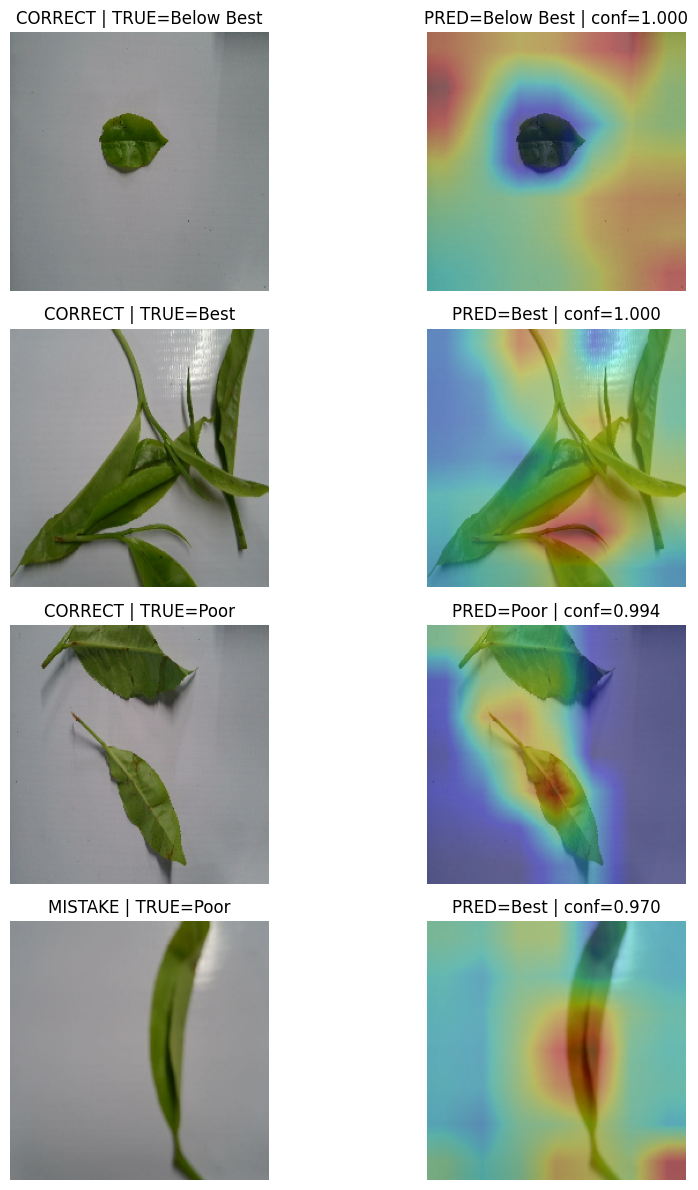


Saved to Drive ✅
Folder: /content/drive/MyDrive/TEAI_Models/gradcam_outputs
Collage: /content/drive/MyDrive/TEAI_Models/gradcam_outputs/gradcam_collage.png


In [42]:
import os
import numpy as np
import tensorflow as tf
from PIL import Image
import matplotlib.pyplot as plt
from matplotlib import cm

# ====== Paths ======
SAVE_PATH = "/content/drive/MyDrive/TEAI_Models/efficientnet_b0_teai.keras"
OUT_DIR = "/content/drive/MyDrive/TEAI_Models/gradcam_outputs"
os.makedirs(OUT_DIR, exist_ok=True)

# ====== Load model safely (Lambda preprocess_input needs custom_objects) ======
from tensorflow.keras.applications.efficientnet import preprocess_input
best = tf.keras.models.load_model(
    SAVE_PATH,
    custom_objects={"preprocess_input": preprocess_input},
    safe_mode=False
)
print("Loaded model ✅")
print("Saving outputs to:", OUT_DIR)

# ====== Find last conv-like layer in the FULL model ======
def find_last_conv_layer_name(model):
    # Try EfficientNet common layer names first
    for name in ["top_conv", "top_activation"]:
        try:
            model.get_layer(name)
            # top_activation isn't conv, but might be right before pooling; prefer top_conv if exists
            if name == "top_conv":
                return name
        except Exception:
            pass

    conv_like = []
    for layer in model.layers:
        if isinstance(layer, (tf.keras.layers.Conv2D,
                              tf.keras.layers.DepthwiseConv2D,
                              tf.keras.layers.SeparableConv2D)):
            try:
                if len(layer.output.shape) == 4:
                    conv_like.append(layer.name)
            except Exception:
                pass

    if not conv_like:
        raise ValueError("Could not find any Conv2D/DepthwiseConv2D layer with 4D output for Grad-CAM.")
    return conv_like[-1]

last_conv_name = find_last_conv_layer_name(best)
print("Grad-CAM target layer:", last_conv_name)

# ====== Grad-CAM core ======
def make_gradcam_heatmap(img_batch, model, conv_layer_name, pred_index=None):
    conv_layer = model.get_layer(conv_layer_name)
    grad_model = tf.keras.Model(
        inputs=model.inputs,
        outputs=[conv_layer.output, model.output]
    )

    with tf.GradientTape() as tape:
        conv_out, preds = grad_model(img_batch, training=False)
        if pred_index is None:
            pred_index = tf.argmax(preds[0])
        class_score = preds[:, pred_index]

    grads = tape.gradient(class_score, conv_out)
    pooled_grads = tf.reduce_mean(grads, axis=(0, 1, 2))

    conv_out = conv_out[0]
    heatmap = tf.reduce_sum(conv_out * pooled_grads, axis=-1)

    heatmap = tf.maximum(heatmap, 0)
    heatmap = heatmap / (tf.reduce_max(heatmap) + 1e-8)
    return heatmap.numpy()

def overlay_heatmap_on_image(img01, heatmap, alpha=0.35):
    # img01: HxWx3 float [0,1]
    h, w = img01.shape[:2]
    heatmap_resized = tf.image.resize(heatmap[..., None], (h, w)).numpy().squeeze()
    heatmap_color = cm.get_cmap("jet")(heatmap_resized)[:, :, :3]
    overlay = (1 - alpha) * img01 + alpha * heatmap_color
    return np.clip(overlay * 255.0, 0, 255).astype(np.uint8)

def save_uint8(img_u8, path):
    Image.fromarray(img_u8).save(path)

# ====== Auto-pick best examples from TEST set ======
CLASS_NAMES = class_folders   # ['Below Best','Best','Poor']
DS = test_ds                 # your integer-label test dataset

num_classes = len(CLASS_NAMES)
best_correct = {i: {"conf": -1.0, "img": None, "true": i, "pred": None} for i in range(num_classes)}
best_mistake = {"conf": -1.0, "img": None, "true": None, "pred": None}

for xb, yb in DS:
    probs = best.predict(xb, verbose=0)
    preds = np.argmax(probs, axis=1)
    confs = np.max(probs, axis=1)

    for i in range(xb.shape[0]):
        true_i = int(yb[i].numpy())
        pred_i = int(preds[i])
        conf_i = float(confs[i])

        if pred_i == true_i and conf_i > best_correct[true_i]["conf"]:
            best_correct[true_i] = {"conf": conf_i, "img": xb[i].numpy(), "true": true_i, "pred": pred_i}

        if pred_i != true_i and conf_i > best_mistake["conf"]:
            best_mistake = {"conf": conf_i, "img": xb[i].numpy(), "true": true_i, "pred": pred_i}

    if all(best_correct[i]["img"] is not None for i in range(num_classes)) and best_mistake["img"] is not None:
        break

print("\nSelected best-correct examples per class:")
for i in range(num_classes):
    info = best_correct[i]
    print(f"  {CLASS_NAMES[i]} -> conf={info['conf']:.4f}")

print("\nSelected most-confident mistake (if exists):")
if best_mistake["img"] is None:
    print("  No misclassified samples found in scanned test batches (awesome).")
else:
    print(f"  true={CLASS_NAMES[best_mistake['true']]}  pred={CLASS_NAMES[best_mistake['pred']]}  conf={best_mistake['conf']:.4f}")

# ====== Generate + Save Grad-CAM outputs ======
items = []
for i in range(num_classes):
    items.append(("CORRECT", best_correct[i]))
if best_mistake["img"] is not None:
    items.append(("MISTAKE", best_mistake))

collage_rows = len(items)
plt.figure(figsize=(10, 3 * collage_rows))

for row, (tag, info) in enumerate(items, start=1):
    img01 = info["img"]  # float 0..1
    true_name = CLASS_NAMES[info["true"]]
    pred_name = CLASS_NAMES[info["pred"]]
    conf = info["conf"]

    heatmap = make_gradcam_heatmap(img01[None, ...], best, last_conv_name, pred_index=info["pred"])
    overlay = overlay_heatmap_on_image(img01, heatmap, alpha=0.35)

    base_name = f"{row:02d}_{tag}_true-{true_name}_pred-{pred_name}_conf-{conf:.3f}".replace(" ", "_")
    orig_path = os.path.join(OUT_DIR, base_name + "_orig.png")
    cam_path  = os.path.join(OUT_DIR, base_name + "_gradcam.png")

    save_uint8((img01 * 255.0).astype(np.uint8), orig_path)
    save_uint8(overlay, cam_path)

    plt.subplot(collage_rows, 2, (row - 1) * 2 + 1)
    plt.imshow((img01 * 255.0).astype(np.uint8))
    plt.title(f"{tag} | TRUE={true_name}")
    plt.axis("off")

    plt.subplot(collage_rows, 2, (row - 1) * 2 + 2)
    plt.imshow(overlay)
    plt.title(f"PRED={pred_name} | conf={conf:.3f}")
    plt.axis("off")

collage_path = os.path.join(OUT_DIR, "gradcam_collage.png")
plt.tight_layout()
plt.savefig(collage_path, dpi=200)
plt.show()

print("\nSaved to Drive ✅")
print("Folder:", OUT_DIR)
print("Collage:", collage_path)

In [43]:
import json
meta = {
  "classes": ["Below Best","Best","Poor"],
  "img_size": 224
}
with open("/content/drive/MyDrive/TEAI_Models/efficientnet_meta.json","w") as f:
    json.dump(meta, f, indent=2)
print("Saved meta ✅")

Saved meta ✅


In [44]:
from google.colab import files
uploaded = files.upload()  # choose your photo
img_path = next(iter(uploaded))  # filename
print("Uploaded:", img_path)

Saving sample_042_20251223_182823_raw.jpg to sample_042_20251223_182823_raw.jpg
Uploaded: sample_042_20251223_182823_raw.jpg


In [45]:
import tensorflow as tf
from tensorflow.keras.applications.efficientnet import preprocess_input

SAVE_PATH = "/content/drive/MyDrive/TEAI_Models/efficientnet_b0_teai.keras"

model = tf.keras.models.load_model(
    SAVE_PATH,
    custom_objects={"preprocess_input": preprocess_input},
    safe_mode=False
)

print("Model loaded ✅")

Model loaded ✅


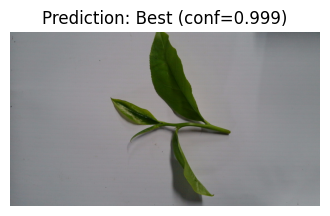

Probabilities:
Below Best  : 0.0009
Best        : 0.9990
Poor        : 0.0001


In [46]:
import numpy as np
from PIL import Image
import matplotlib.pyplot as plt

IMG_SIZE = 224

# make sure this matches your saved class order
class_names = ['Below Best', 'Best', 'Poor']  # adjust if your class_folders order differs

# Load + resize
img = Image.open(img_path).convert("RGB")
img_resized = img.resize((IMG_SIZE, IMG_SIZE))

# Convert to array (0..1 float)
x = np.array(img_resized).astype(np.float32) / 255.0
x = np.expand_dims(x, axis=0)  # (1,224,224,3)

# Predict
probs = model.predict(x, verbose=0)[0]
pred_id = int(np.argmax(probs))
pred_label = class_names[pred_id]
conf = float(probs[pred_id])

# Show result
plt.figure(figsize=(4,4))
plt.imshow(img)
plt.title(f"Prediction: {pred_label} (conf={conf:.3f})")
plt.axis("off")
plt.show()

print("Probabilities:")
for name, p in zip(class_names, probs):
    print(f"{name:12s}: {p:.4f}")

# Setup (Mount Drive + Load Model once)

In [48]:
# =========================
# TEAI SETUP (Run Once)
# Mount Drive + Load EfficientNet Model
# =========================

from google.colab import drive
drive.mount("/content/drive")

import tensorflow as tf
from tensorflow.keras.applications.efficientnet import preprocess_input

SAVE_PATH = "/content/drive/MyDrive/TEAI_Models/efficientnet_b0_teai.keras"
IMG_SIZE = 224
CLASS_NAMES = ["Below Best", "Best", "Poor"]  # update only if your class order differs

model = tf.keras.models.load_model(
    SAVE_PATH,
    custom_objects={"preprocess_input": preprocess_input},
    safe_mode=False
)

print("✅ Drive mounted and model loaded!")
print("Model path:", SAVE_PATH)
print("Classes:", CLASS_NAMES)

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
✅ Drive mounted and model loaded!
Model path: /content/drive/MyDrive/TEAI_Models/efficientnet_b0_teai.keras
Classes: ['Below Best', 'Best', 'Poor']


Upload an image now...


Saving sample_069_20251122_210846.jpg to sample_069_20251122_210846.jpg
Uploaded: sample_069_20251122_210846.jpg


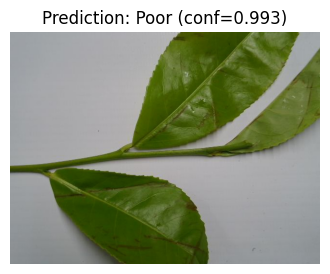

Probabilities:
Below Best  : 0.0000
Best        : 0.0069
Poor        : 0.9931


In [50]:
# =========================
# TEAI PREDICT
# Upload 1 Image and Get Prediction
# =========================

from google.colab import files
import numpy as np
from PIL import Image
import matplotlib.pyplot as plt

print("Upload an image now...")
uploaded = files.upload()
if not uploaded:
    raise RuntimeError("No file uploaded. Run the cell again and choose an image.")

img_path = next(iter(uploaded))
print("Uploaded:", img_path)

img = Image.open(img_path).convert("RGB")
img_resized = img.resize((IMG_SIZE, IMG_SIZE))

x = np.array(img_resized).astype(np.float32) / 255.0
x = np.expand_dims(x, axis=0)

probs = model.predict(x, verbose=0)[0]
pred_id = int(np.argmax(probs))
pred_label = CLASS_NAMES[pred_id]
conf = float(probs[pred_id])

plt.figure(figsize=(4, 4))
plt.imshow(img)
plt.title(f"Prediction: {pred_label} (conf={conf:.3f})")
plt.axis("off")
plt.show()

print("Probabilities:")
for name, p in zip(CLASS_NAMES, probs):
    print(f"{name:12s}: {p:.4f}")